# Applying the changes we make to the JdF boundary to the Johnstone boundary
Taking salinity binned changes averaged over a month, over the whole five years that we looked at and applying it to the Johnstone Strait monthly climatology

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cm
import pandas as pd
import gsw
from salishsea_tools.LiveOcean_BCs import convect, stabilize

In [2]:
NitData = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/bioOBC_North_monthlySiNO3.nc')
OxData = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/tr_northDICTAOXY.nc', decode_times=False)
Cdata = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/Dosser_north_TEOS10_DICTA.nc')

salinity and temperature from both Dosser files are the same so just need to use/edit "Dosser_north_TEOS10_DICTA.nc"

In [3]:
NitData

<xarray.Dataset> Size: 1MB
Dimensions:       (yb: 10, xbT: 30, time_counter: 12, deptht: 40)
Coordinates:
  * time_counter  (time_counter) float32 48B 1.0 2.0 3.0 4.0 ... 10.0 11.0 12.0
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
Dimensions without coordinates: yb, xbT
Data variables:
    nav_lat       (yb, xbT) float32 1kB ...
    nav_lon       (yb, xbT) float32 1kB ...
    NO3           (time_counter, deptht, yb, xbT) float32 576kB ...
    Si            (time_counter, deptht, yb, xbT) float32 576kB ...

In [4]:
OxData

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 2, deptht: 40, yb: 1, xbT: 300)
Coordinates:
  * time_counter  (time_counter) float32 8B 0.0 1.0
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
Dimensions without coordinates: yb, xbT
Data variables: (12/20)
    CRY           (time_counter, deptht, yb, xbT) float32 96kB ...
    DIA           (time_counter, deptht, yb, xbT) float32 96kB ...
    DIC           (time_counter, deptht, yb, xbT) float64 192kB ...
    DON           (time_counter, deptht, yb, xbT) float32 96kB ...
    MICZ          (time_counter, deptht, yb, xbT) float32 96kB ...
    MYRI          (time_counter, deptht, yb, xbT) float32 96kB ...
    ...            ...
    nav_lat       (yb, xbT) float32 1kB ...
    nav_lon       (yb, xbT) float32 1kB ...
    nbidta        (yb, xbT) int32 1kB ...
    nbjdta        (yb, xbT) int32 1kB ...
    nbrdta        (yb, xbT) int32 1kB ...
    tur           (time_counter, deptht, yb, xbT) float32 96kB ...
Attributes:
    history:  Sun Aug  5 15:38:55 2018: ncks -4 -L4 -O tr_northDICTAOXY.nc tr...
    NCO:      4.4.2

In [5]:
Cdata

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 12, deptht: 40, yb: 10, xbT: 30)
Coordinates:
  * time_counter  (time_counter) float32 48B 1.0 2.0 3.0 4.0 ... 10.0 11.0 12.0
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
Dimensions without coordinates: yb, xbT
Data variables:
    DIC           (time_counter, deptht, yb, xbT) float32 576kB ...
    TA            (time_counter, deptht, yb, xbT) float32 576kB ...
    vosaline      (time_counter, deptht, yb, xbT) float32 576kB ...
    votemper      (time_counter, deptht, yb, xbT) float32 576kB ...
Attributes:
    history:  Tue Apr  9 09:39:51 2019: ncks -4 -L4 -o Dosser_north_TEOS10_DI...
    NCO:      4.4.2

In [6]:
# combine all three datasets into one
# Variables to keep
nit_vars = ["NO3", "Si"]
c_vars   = ["DIC", "TA", "vosaline", "votemper"]
ox_var   = "OXY"

# get oxygen dataset into the same format as the others
oxy_flat = OxData[ox_var].isel(time_counter=0) # remove unncessary timestep
oxy_flat = oxy_flat.squeeze("yb", drop=True) # get rid of dummy yb

n_yb = NitData.sizes["yb"] # get sizes from nit data
n_xbT = NitData.sizes["xbT"]

# Reshape to: deptht, yb, xbT
oxy_arr = oxy_flat.values
oxy_arr = oxy_arr.reshape(
    oxy_flat.sizes["deptht"],
    n_yb,
    n_xbT,
)

# Add time dimension and repeat:
#   time_counter, deptht, yb, xbT
n_time = NitData.sizes["time_counter"]
oxy_arr_12 = np.repeat(
    oxy_arr[np.newaxis, :, :, :],
    n_time,
    axis=0,
)

# Create a proper xarray DataArray using NitData coordinates
OXY_fixed = xr.DataArray(
    oxy_arr_12,
    dims=("time_counter", "deptht", "yb", "xbT"),
    coords={
        "time_counter": NitData["time_counter"],
        "deptht": NitData["deptht"],
        "yb": NitData["yb"],
        "xbT": NitData["xbT"],
    },
    name="OXY",
    attrs=OxData[ox_var].attrs,
)

# merge into one dataset
data = xr.merge([
    NitData[nit_vars],
    Cdata[c_vars],
    OXY_fixed.to_dataset(),
])

# and save!
data.to_netcdf("/ocean/rbeutel/MOAD/analysis-becca/projections/output/Original_Johnstone_bdy.nc")


In [7]:
data
# I'm assuming that the setup is the cross section is 30 across and has a thickness of 10 rows - like the JdF boundary just setup a little differently 

<xarray.Dataset> Size: 5MB
Dimensions:       (time_counter: 12, deptht: 40, yb: 10, xbT: 30)
Coordinates:
  * time_counter  (time_counter) float32 48B 1.0 2.0 3.0 4.0 ... 10.0 11.0 12.0
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * yb            (yb) int64 80B 0 1 2 3 4 5 6 7 8 9
  * xbT           (xbT) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29
Data variables:
    NO3           (time_counter, deptht, yb, xbT) float32 576kB ...
    Si            (time_counter, deptht, yb, xbT) float32 576kB ...
    DIC           (time_counter, deptht, yb, xbT) float32 576kB ...
    TA            (time_counter, deptht, yb, xbT) float32 576kB ...
    vosaline      (time_counter, deptht, yb, xbT) float32 576kB ...
    votemper      (time_counter, deptht, yb, xbT) float32 576kB ...
    OXY           (time_counter, deptht, yb, xbT) float64 1MB 184.0 ... 79.31

In [22]:
original_df = {
    "salt":       data["vosaline"][0, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       data["votemper"][0, :, :, :].values.copy(),
    "oxygen":     data["OXY"][0, :, :, :].values.copy(),
    "NO3":        data["NO3"][0, :, :, :].values.copy(),
    "TIC":        data["DIC"][0, :, :, :].values.copy(),
    "alkalinity": data["TA"][0, :, :, :].values.copy(),
}

df = {k: v.copy() for k, v in original_df.items()}

In [23]:
np.min(data.vosaline.values)

np.float32(30.442507)

In [24]:
np.max(data.vosaline.values)

np.float32(32.172688)

very small range in salt!

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

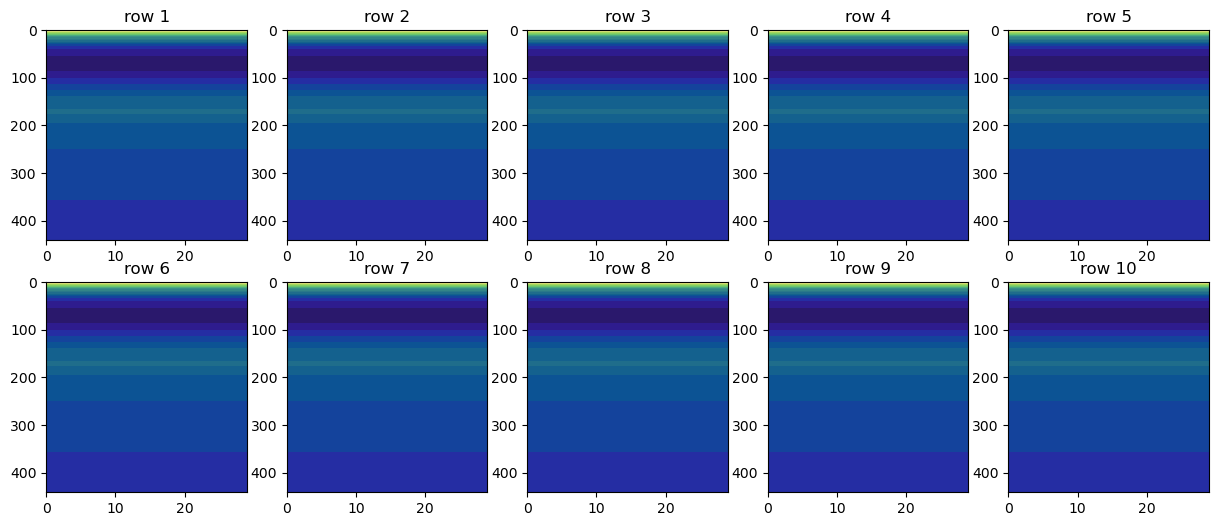

In [25]:
# vmin, vmax = np.min(data.votemper.values),np.max(data.votemper.values)
vmin, vmax = np.min(original_df['temp']),np.max(original_df['temp'])
X, Y = np.meshgrid(data.xbT.values,data.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    temp = original_df['temp'][:,i,:]
    cs = ax[row,column].contourf(X,Y,temp,levels=20,cmap=cm.haline_r,vmin=vmin,vmax=vmax)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

## going from JdF change to Johnstone change
test with south source water change

In [26]:
# bring in water mass fraction data
fsouth = pd.read_csv('./output/inflowfraction_D_south.csv').drop(columns=['Unnamed: 0'])
fcuc = pd.read_csv('./output/inflowfraction_D_cuc.csv').drop(columns=['Unnamed: 0'])

In [27]:
# get depth fraction profile of a certain water mass on a specific day 
def get_depth_profile(df, date_str):
    row = df.loc[df["day"] == date_str]
    prof = row.select_dtypes(include=np.number).to_numpy().squeeze()
    return prof  # shape (40,)

def salinity_binned_delta(S_source, delta_source, S_target, salinity_edges):
    """
    Map source anomalies onto target cells by salinity bin.

    S_source: JdF salinity array
    delta_source: JdF anomaly array for any variable
    S_target: Johnstone salinity array
    salinity_edges: 1-D salinity bin edges

    Returns
    -------
    delta_target: anomaly field with same shape as S_target
    """

    bin_centres = 0.5 * (salinity_edges[:-1] + salinity_edges[1:])
    mean_delta = np.full(len(bin_centres), np.nan)

    for i in range(len(bin_centres)):
        Smin = salinity_edges[i]
        Smax = salinity_edges[i + 1]

        mask = (S_source >= Smin) & (S_source < Smax)

        if np.any(mask):
            mean_delta[i] = np.nanmean(delta_source[mask])

    valid = np.isfinite(mean_delta)

    if valid.sum() < 2:
        raise ValueError("Not enough populated salinity bins to interpolate anomalies.")

    # interpolate missing salinity bins
    mean_delta_filled = np.interp(
        bin_centres,
        bin_centres[valid],
        mean_delta[valid],
    )

    # assign target cells by interpolating directly from salinity
    delta_target = np.interp(
        S_target.ravel(),
        bin_centres,
        mean_delta_filled,
        left=mean_delta_filled[0],
        right=mean_delta_filled[-1],
    ).reshape(S_target.shape)

    return delta_target

In [28]:
# bring in JdF data

day1 = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2018m01d01.nc')
original_jdf = {
    "salt":       day1["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       day1["votemper"][0, :, :, :].values.copy(),
    "NO3":        day1["NO3"][0, :, :, :].values.copy(),
    "Si":         day1["Si"][0, :, :, :].values.copy(),
    "oxygen":     day1["OXY"][0, :, :, :].values.copy(),
    "TIC":        day1["DIC"][0, :, :, :].values.copy(),
    "alkalinity": day1["TA"][0, :, :, :].values.copy(),
}

day1 = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_SouthChange/LiveOcean_v201905_y2018m01d01.nc')
interps_jdf = {
    "salt":       day1["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       day1["votemper"][0, :, :, :].values.copy(),
    "NO3":        day1["NO3"][0, :, :, :].values.copy(),
    "Si":         day1["Si"][0, :, :, :].values.copy(),
    "oxygen":     day1["OXY"][0, :, :, :].values.copy(),
    "TIC":        day1["DIC"][0, :, :, :].values.copy(),
    "alkalinity": day1["TA"][0, :, :, :].values.copy(),
}



In [29]:
S_jdf = original_jdf["salt"].copy()
S_north = df["salt"].copy()

salinity_edges = np.arange(np.min(data.vosaline.values),np.max(data.vosaline.values), 0.1)

df["salt"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["salt"] - original_jdf["salt"],
    S_north,
    salinity_edges,
)

df["temp"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["temp"] - original_jdf["temp"],
    S_north,
    salinity_edges,
)

df["oxygen"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["oxygen"] - original_jdf["oxygen"],
    S_north,
    salinity_edges,
)

df["NO3"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["NO3"] - original_jdf["NO3"],
    S_north,
    salinity_edges,
)

df["alkalinity"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["alkalinity"] - original_jdf["alkalinity"],
    S_north,
    salinity_edges,
)

df["TIC"] += salinity_binned_delta(
    S_jdf,
    interps_jdf["TIC"] - original_jdf["TIC"],
    S_north,
    salinity_edges,
)

In [30]:
# STABILIZE 

# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(df['salt'], df['temp']) # need density first
sigma, df = convect(sigma, df)

# stabilize (small changes to salinity to stabilize marginally stable cells)
df = stabilize(sigma, df)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

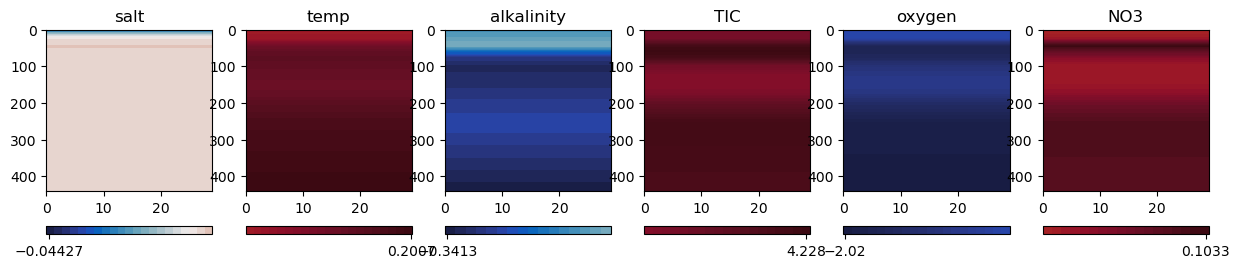

In [56]:
# vmin, vmax = np.min(data.votemper.values),np.max(data.votemper.values)
# vmin, vmax = np.min(original_df['temp']),np.max(original_df['temp'])
X, Y = np.meshgrid(data.xbT.values,data.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = df[tracers[i]][:,i,:]-original_df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.balance,vmin=-np.max(abs(temp)),vmax=np.max(abs(temp)))
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[-np.max(abs(temp)),np.max(abs(temp))])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

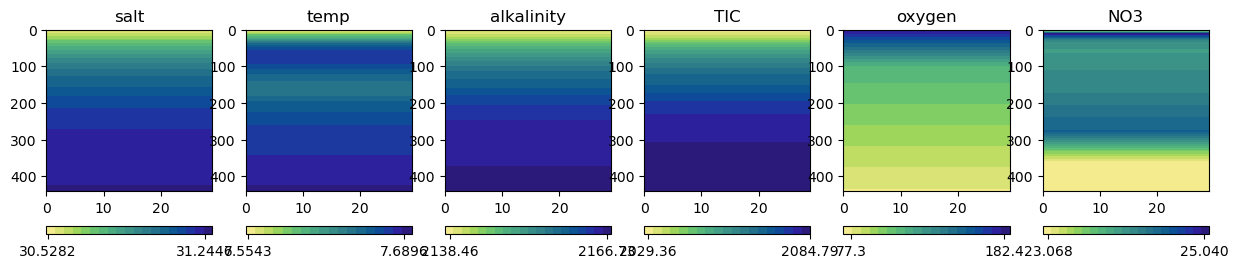

In [55]:
X, Y = np.meshgrid(data.xbT.values,data.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

# check of boundary files
note that it will look different because the changes we made above where for 1 day, not averaged over a full month

## south change

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

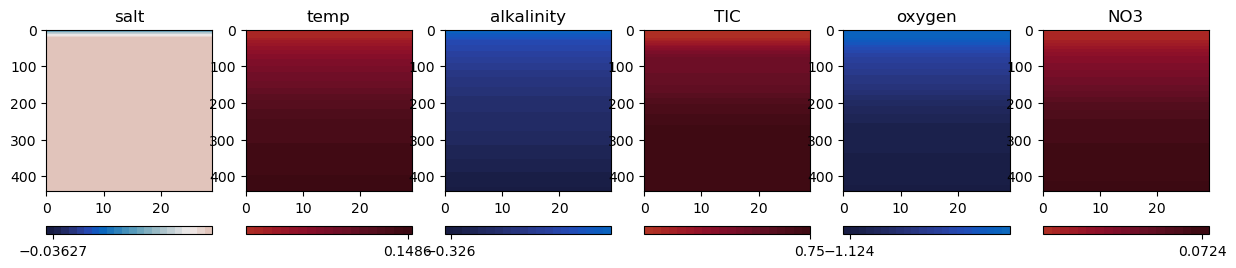

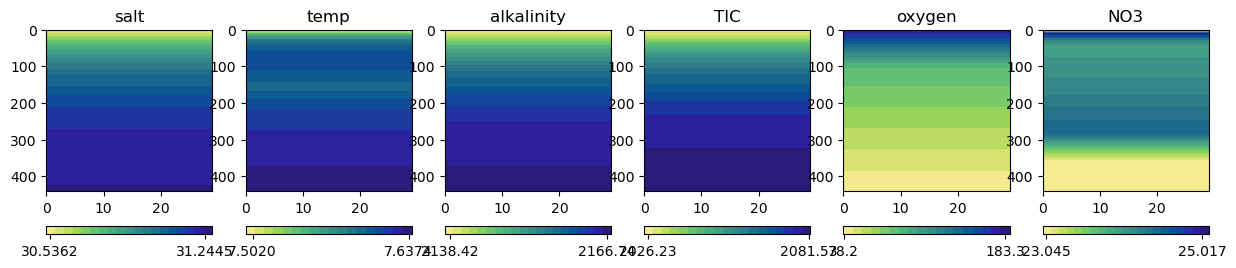

In [58]:
file = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_SouthChange/Johnstone_bdy.nc")

check = {
    "salt":       file["vosaline"][0, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       file["votemper"][0, :, :, :].values.copy(),
    "oxygen":     file["OXY"][0, :, :, :].values.copy(),
    "NO3":        file["NO3"][0, :, :, :].values.copy(),
    "TIC":        file["DIC"][0, :, :, :].values.copy(),
    "alkalinity": file["TA"][0, :, :, :].values.copy(),
}

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]-original_df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.balance,vmin=-np.max(abs(temp)),vmax=np.max(abs(temp)))
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[-np.max(abs(temp)),np.max(abs(temp))])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

## north/west change

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

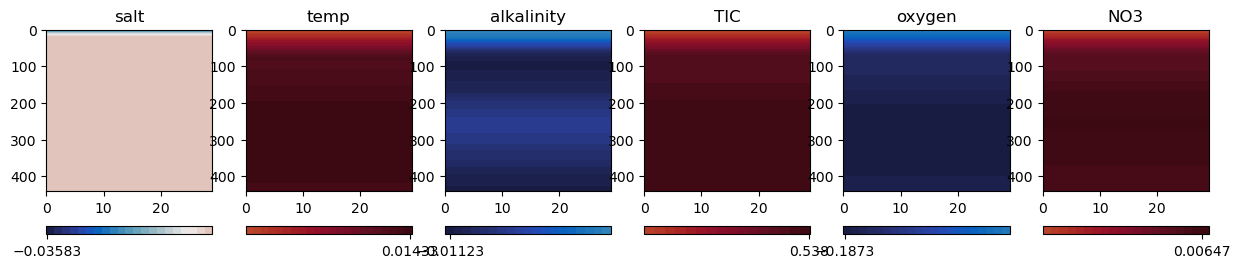

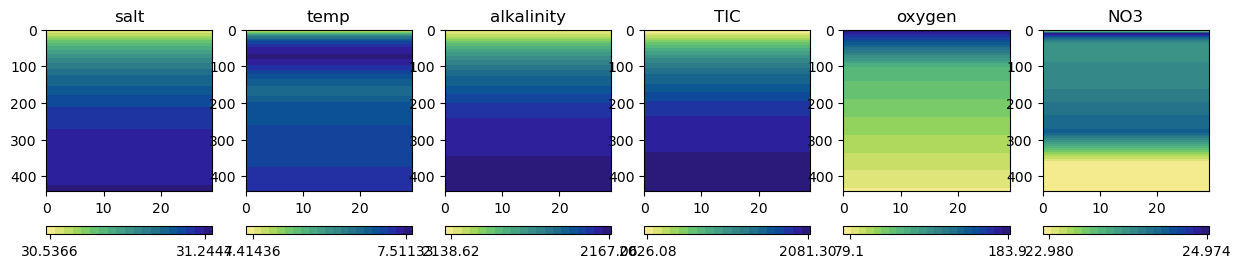

In [59]:
file = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_NorthWestChange/Johnstone_bdy.nc")

check = {
    "salt":       file["vosaline"][0, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       file["votemper"][0, :, :, :].values.copy(),
    "oxygen":     file["OXY"][0, :, :, :].values.copy(),
    "NO3":        file["NO3"][0, :, :, :].values.copy(),
    "TIC":        file["DIC"][0, :, :, :].values.copy(),
    "alkalinity": file["TA"][0, :, :, :].values.copy(),
}

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]-original_df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.balance,vmin=-np.max(abs(temp)),vmax=np.max(abs(temp)))
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[-np.max(abs(temp)),np.max(abs(temp))])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

## Upwelling change

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

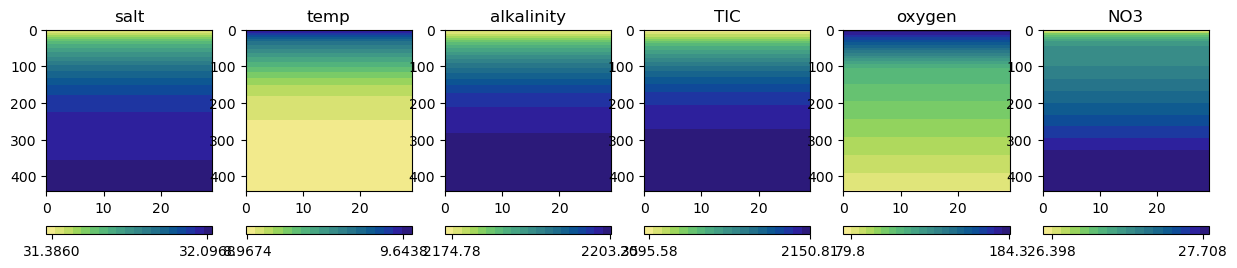

In [61]:
file = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_UpwellingChange/Johnstone_bdy.nc")

check = {
    "salt":       file["vosaline"][8, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       file["votemper"][8, :, :, :].values.copy(),
    "oxygen":     file["OXY"][8, :, :, :].values.copy(),
    "NO3":        file["NO3"][8, :, :, :].values.copy(),
    "TIC":        file["DIC"][8, :, :, :].values.copy(),
    "alkalinity": file["TA"][8, :, :, :].values.copy(),
}

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

## local change

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

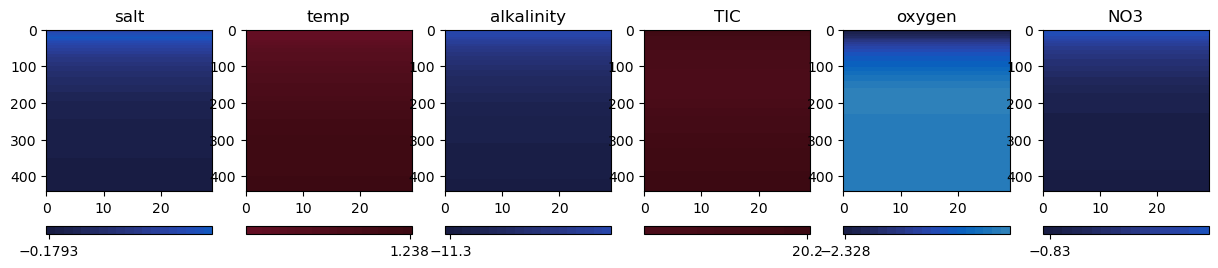

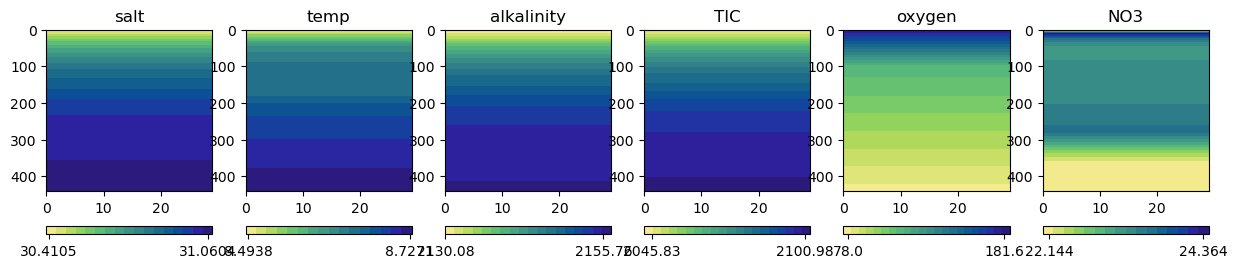

In [62]:
file = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_LocalChange/Johnstone_bdy.nc")

check = {
    "salt":       file["vosaline"][0, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       file["votemper"][0, :, :, :].values.copy(),
    "oxygen":     file["OXY"][0, :, :, :].values.copy(),
    "NO3":        file["NO3"][0, :, :, :].values.copy(),
    "TIC":        file["DIC"][0, :, :, :].values.copy(),
    "alkalinity": file["TA"][0, :, :, :].values.copy(),
}

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]-original_df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.balance,vmin=-np.max(abs(temp)),vmax=np.max(abs(temp)))
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[-np.max(abs(temp)),np.max(abs(temp))])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

## all change

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

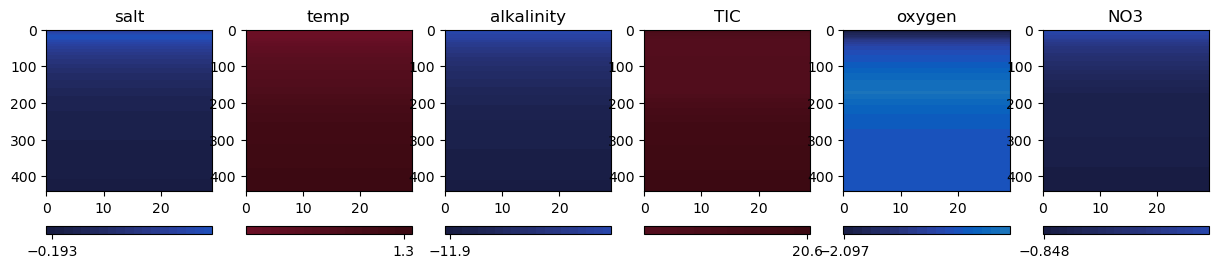

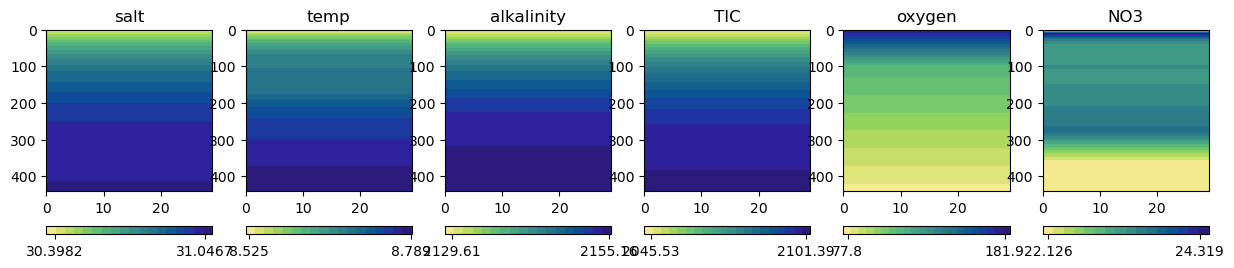

In [63]:
file = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/Johnstone_bdy.nc")

check = {
    "salt":       file["vosaline"][0, :, :, :].values.copy(),   # just taking january, [40,10,30]
    "temp":       file["votemper"][0, :, :, :].values.copy(),
    "oxygen":     file["OXY"][0, :, :, :].values.copy(),
    "NO3":        file["NO3"][0, :, :, :].values.copy(),
    "TIC":        file["DIC"][0, :, :, :].values.copy(),
    "alkalinity": file["TA"][0, :, :, :].values.copy(),
}

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]-original_df[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.balance,vmin=-np.max(abs(temp)),vmax=np.max(abs(temp)))
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[-np.max(abs(temp)),np.max(abs(temp))])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout

X, Y = np.meshgrid(file.xbT.values,file.deptht.values)

tracers = ['salt','temp','alkalinity','TIC','oxygen','NO3']

fig, ax = plt.subplots(1,6,figsize=[15,3])

for i in range(6):

    title=tracers[i]
    ax[i].set_title(title)
    temp = check[tracers[i]][:,i,:]
    cs = ax[i].contourf(X,Y,temp,levels=20,cmap=cm.haline_r)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[np.min(temp),np.max(temp)])
    ax[i].set_ylim([np.max(Y),0])

plt.tight_layout